<a href="https://colab.research.google.com/github/manuelorlopez89-rgb/sprint7-connectatel/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
print("*** PRIMERAS FILAS DE PLANS ***")
plans.head()

*** PRIMERAS FILAS DE PLANS ***


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
print("\n*** PRIMERAS FILAS DE USERS ***")
users.head()


*** PRIMERAS FILAS DE USERS ***


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
print("\n*** PRIMERAS FILAS DE USAGE ***")
usage.head()


*** PRIMERAS FILAS DE USAGE ***


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:

# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)


plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print("Cantidad de valores nulos:")
print(users.isnull().sum())

print("\nProporción de valores nulos:")
print(users.isnull().mean())

Cantidad de valores nulos:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print("Cantidad de valores nulos:")
print(usage.isnull().sum())

print("\nProporción de valores nulos:")
print(usage.isnull().mean())

Cantidad de valores nulos:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


* ['churn_date']:Representa a los usuarios que siguen activos en el servicio, por lo que el valor nulo no es una falta de información sino una condición de negocio.
* ['city']: Se encuentra en el rango de 5% a 30% de nulos, reemplazar los nulos y los valores centinela por "Desconocido".
* ['date']: su porcentaje es minimo, se puede eliminar o imputar.
* En las otras dos columnas se espera valores nulos ya que son mensajes y llamadas por eso el alto porcentaje.

 ---

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- Al aplicar .describe(), confirmamos la presencia del valor centinela -999 en la columna age, lo cual distorsiona la media (33.7 años) en comparación con la mediana (47 años). Se debe reemplazar -999 por NaN antes de realizar análisis estadísticos.

In [ ]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- no se nota algo inusual, los porcentajes y medidas son las esperadas.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"** COLUMNA: {col} **")
    print("Valores únicos:", users[col].unique())
    print("\nConteo de frecuencias (incluyendo nulos):")
    print(users[col].value_counts(dropna=False))
    print("-" * 40)


** COLUMNA: city **
Valores únicos: ['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

Conteo de frecuencias (incluyendo nulos):
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
----------------------------------------
** COLUMNA: plan **
Valores únicos: ['Basico' 'Premium']

Conteo de frecuencias (incluyendo nulos):
Basico     2595
Premium    1405
Name: plan, dtype: int64
----------------------------------------


- La columna `city` * Presenta dos problemas que representan el **14.1% del total de datos, accion de reemplazar '?' e imputar con 'desconocido'
- La columna `plan` * La columna no presenta ningún problema de calidad de datos

In [ ]:

# explorar columna categórica de usage
usage['type'].value_counts(dropna=False)



text    22092
call    17908
Name: type, dtype: int64

- La columna `type` Me muestra que solo hay dos catyegorias 'text' y 'call' con datos normales.


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')


In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`: aparecen 40 registros con año 2026, a mi parecer son datos 'invalidos' ya que dice que solo se tiene registro hasta el 2024.
* Mi recomendacion es marcarlos como Nat.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts(dropna=False).sort_index()


2024.0    39950
NaN          50
Name: date, dtype: int64


En `date`, encontre el año 2024 con 50 valores nulos que vienen de fechas invalidas o mal formateados.
* Mi sugerencia es eliminarlos ya que representan un minimo de datos y no afectan al analisis.


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users[users['age'] > 0]['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:

# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', np.nan)


# Verificar cambios
print("Conteo de valores en 'city' (incluyendo nulos):")
print(users['city'].value_counts(dropna=False))

print("\nCantidad total de nulos en 'city':", users['city'].isna().sum())



Conteo de valores en 'city' (incluyendo nulos):
Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

Cantidad total de nulos en 'city': 565


In [ ]:

# Marcar fechas futuras como NA para reg_date
fecha_limite = pd.to_datetime('2024-12-31')
users.loc[users['reg_date'] > fecha_limite, 'reg_date'] = pd.NaT

print(users['reg_date'].max())
print(fecha_limite)


2024-12-31 00:00:00
2024-12-31 00:00:00


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
print(" Distribución de nulos en 'duration' por tipo de evento ")
print(usage[usage['duration'].isna()]['type'].value_counts(dropna=False))

 Distribución de nulos en 'duration' por tipo de evento 
text    22076
Name: type, dtype: int64


In [ ]:
# Verificación MAR en usage (Missing At Random) para length
print("\n Distribución de nulos en 'length' por tipo de evento")
print(usage[usage['length'].isna()]['type'].value_counts(dropna=False))


 Distribución de nulos en 'length' por tipo de evento
call    17896
Name: type, dtype: int64


* La variable `duration` solo aplica para registros de llamadas (`call`).
* * La variable `length` solo aplica para registros de SMS (`sms`).
  * Decisión tomada: **Mantener los valores nulos.**

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    cant_mensajes=("is_text", "sum"),
    cant_llamadas=("is_call", "sum"),
    cant_minutos_llamada=("duration", "sum")
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on='user_id', how='left')

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

print("** Resumen estadístico de variables numéricas **")
display(user_profile[columnas_numericas].describe().T[['count', 'mean', 'std', 'min', '50%', 'max']])

** Resumen estadístico de variables numéricas **


,count,mean,std,min,50%,max
age,4000.0,48.136000,17.689919,18.0,48.00,79.00
cant_mensajes,3999.0,5.524381,2.358416,0.0,5.00,17.00
cant_llamadas,3999.0,4.478120,2.144238,0.0,4.00,15.00
cant_minutos_llamada,3999.0,23.317054,18.168095,0.0,19.78,155.69


In [ ]:
# Distribución porcentual del tipo de plan
print("\n** Distribución de usuarios por tipo de plan (%) *")
distribucion_plan = user_profile['plan'].value_counts(normalize=True) * 100
display(distribucion_plan.round(2).astype(str) + '%')



** Distribución de usuarios por tipo de plan (%) *


Basico     64.88%
Premium    35.12%
Name: plan, dtype: object

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

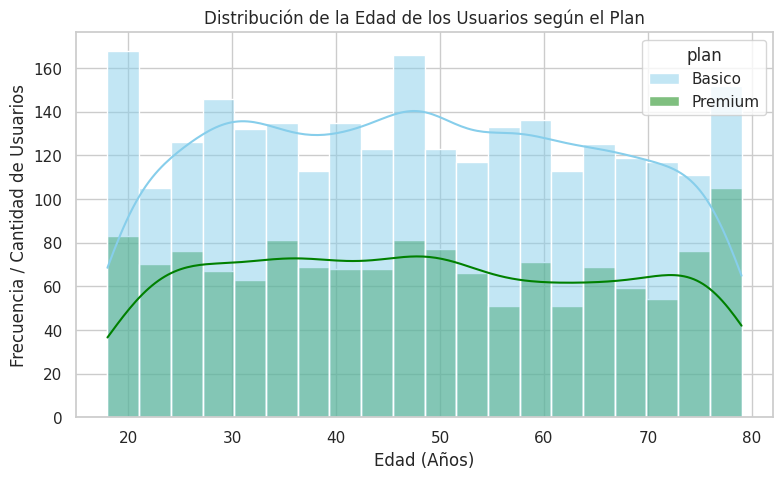

In [ ]:
# Histograma para visualizar la edad (age)
# Configuración general de estilo
sns.set_theme(style="whitegrid")
paleta_planes = ['skyblue', 'green']

# Histograma para visualizar la edad (age)
plt.figure(figsize=(9, 5))
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=paleta_planes,
    kde=True,
    bins=20
)
plt.title('Distribución de la Edad de los Usuarios según el Plan')
plt.xlabel('Edad (Años)')
plt.ylabel('Frecuencia / Cantidad de Usuarios')
plt.show()

💡Insights:
-"La distribución de edad es simétrica entre los 18 y 79 años. El plan básico predomina en casi todos los rangos de edad, probablemente por ser más accesible económicamente, mientras que el plan premium aumenta notablemente entre los 75 y 80 años, lo que podría explicarse porque las personas mayores suelen tener menos gastos fijos (hijos, hipoteca, etc.) y pueden permitirse un plan de mayor costo.

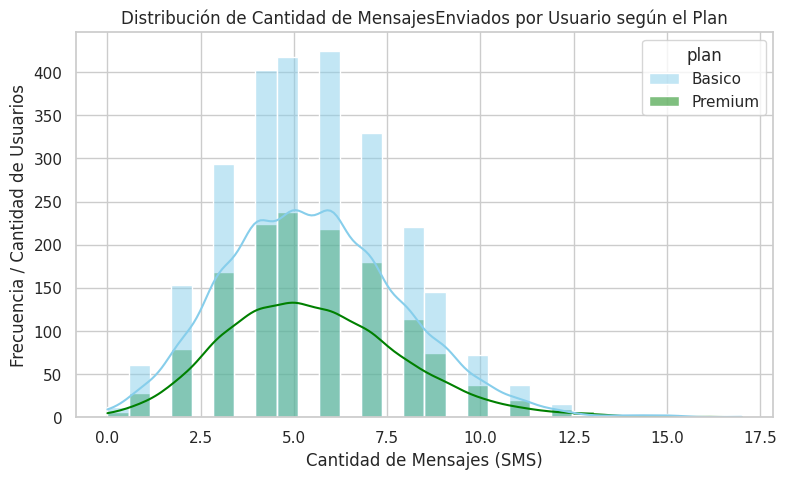

In [ ]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(9, 5))
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=paleta_planes,
    kde=True,
    bins=30
)
plt.title('Distribución de Cantidad de MensajesEnviados por Usuario según el Plan')
plt.xlabel('Cantidad de Mensajes (SMS)')
plt.ylabel('Frecuencia / Cantidad de Usuarios')
plt.show()


💡Insights:
- Sesgada a la derecha "Con cola larga hacia los valores altos", la mayoria de usuario envia pocos o bajos (sms) solo un bajo porcentaje sobrepasa la media de los sms, el usuario premium es quien mas sms envia.
- Usuarios Premium utilizan mas el servicio de SMS por la cantidad que ofrece el paquete de SMS (500) sobre los (100) del basico

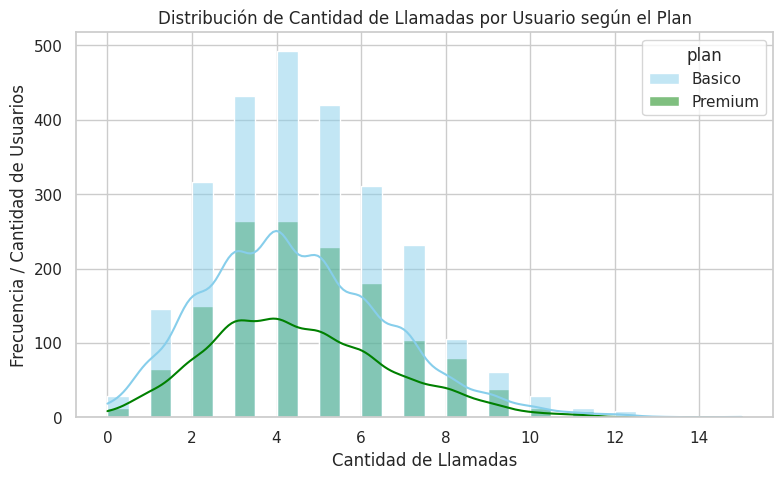

In [ ]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(9, 5))
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=paleta_planes,
    kde=True,
    bins=30
)
plt.title('Distribución de Cantidad de Llamadas por Usuario según el Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Frecuencia / Cantidad de Usuarios')
plt.show()

💡Insights:
- La distribución está sesgada a la derecha, con la mayoría de usuarios realizando entre 2 y 8 llamadas, y muy pocos superando las 20 llamadas. Los usuarios Premium tienden a realizar más llamadas que los Básico, lo cual es consistente con que su plan incluye 600 minutos frente a los 100 minutos del plan Básico.

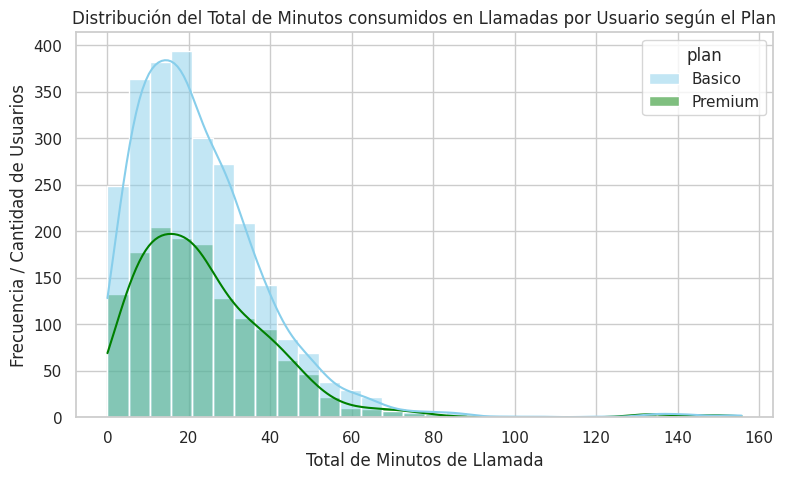

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(9, 5))
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=paleta_planes,
    kde=True,
    bins=30
)
plt.title('Distribución del Total de Minutos consumidos en Llamadas por Usuario según el Plan')
plt.xlabel('Total de Minutos de Llamada')
plt.ylabel('Frecuencia / Cantidad de Usuarios')
plt.show()

💡Insights:
- Sesgada a la derecha (valores altos)
- Los usuarios del plan Premium presentan un consumo acumulado de minutos mucho más amplio y extendido hacia la derecha. Los usuarios del plan Básico concentran la mayor parte de su distribución en valores bajos de consumo de minutos, marcando un patrón claro de segmentación por tipo de suscripción.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

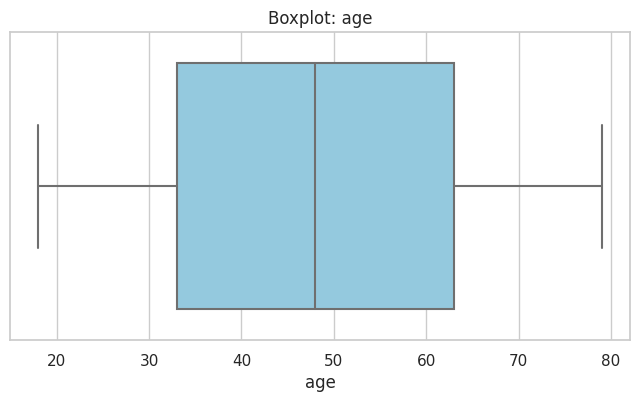

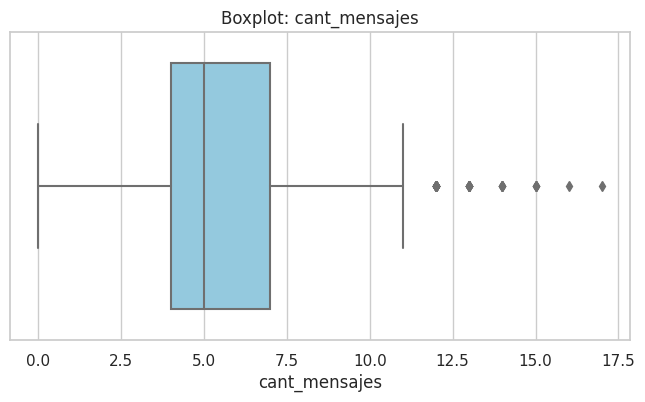

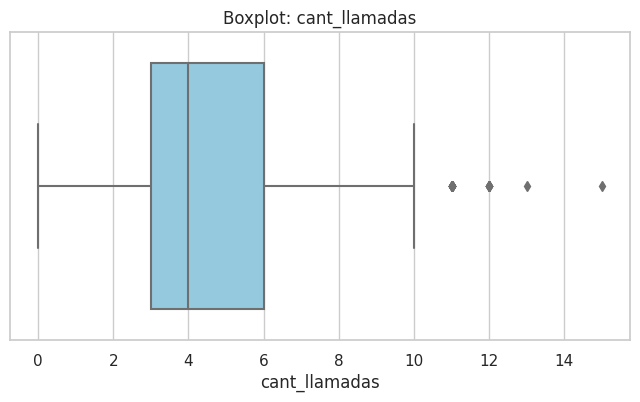

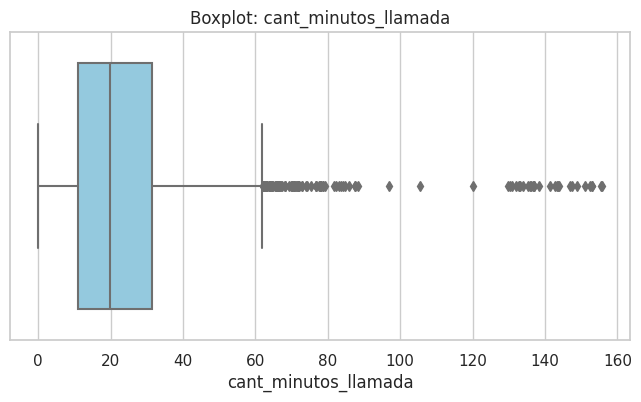

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights:
- Age: No presenta outliers, la distribucion esta contenida dentro de las cajas.
- cant_mensajes: Si presenta outliers. Hay múltiples puntos a la derecha del bigote superior (valores extremos altos).
- cant_llamadas: S presenta outliers. Se observan valores atípicos concentrados hacia la derecha.
- cant_minutos_llamada: Sí presenta outliers. Existen valores extremos en la parte superior del consumo de minutos.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + (1.5 * IQR)

    print(f"*** {col} ***")
    print(f"Límite Superior (IQR): {limite_superior:.2f}")
    print(f"Valor Máximo Real: {user_profile[col].max():.2f}\n")



*** cant_mensajes ***
Límite Superior (IQR): 11.50
Valor Máximo Real: 17.00

*** cant_llamadas ***
Límite Superior (IQR): 10.50
Valor Máximo Real: 15.00

*** cant_minutos_llamada ***
Límite Superior (IQR): 61.86
Valor Máximo Real: 155.69



In [ ]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe().T[['min', '50%', '75%', 'max']]


,min,50%,75%,max
cant_mensajes,0.0,5.00,7.000,17.00
cant_llamadas,0.0,4.00,6.000,15.00
cant_minutos_llamada,0.0,19.78,31.415,155.69


💡Insights:
- cant_mensajes: Mantener los outliers. Es normal que existan usuarios que envíen un volumen alto de mensajes (especialmente en planes ilimitados/Premium).No son errores de captura sino algo hasta normal y que ayudan a comprender mejor el negocio.
- cant_llamadas: Mantener los outliers. Eliminar estos datos perjudicaria a la baja las estimaciones de carga en la red telefónica y el calculo del cliente
- cant_minutos_llamada: Mantener los outliers. Es parte normal del comportamiento del cliente en consumos largos de llamadas y sus datos es muy importante para decisiones sobre nuevos productos.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
# 1. Definir las condiciones lógicas en orden de evaluación
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),  # Bajo uso
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)  # Uso medio
]
# 2. Definir las etiquetas/categorías correspondientes
opciones = ['Bajo uso', 'Uso medio']

# 3. Crear la columna asignando 'Alto uso' por defecto a todos los demás casos
user_profile['grupo_uso'] = np.select(condiciones, opciones, default='Alto uso')


In [ ]:

# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
# 1. Definir las condiciones lógicas en orden
condiciones_edad = [
    user_profile['age'] < 30,  # Joven
    user_profile['age'] < 60   # Adulto
]
# 2. Definir las etiquetas correspondientes
opciones_edad = ['Joven', 'Adulto']

# 3. Crear la columna asignando 'Adulto Mayor' a los casos restantes (>= 60)
user_profile['grupo_edad'] = np.select(condiciones_edad, opciones_edad, default='Adulto Mayor')


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

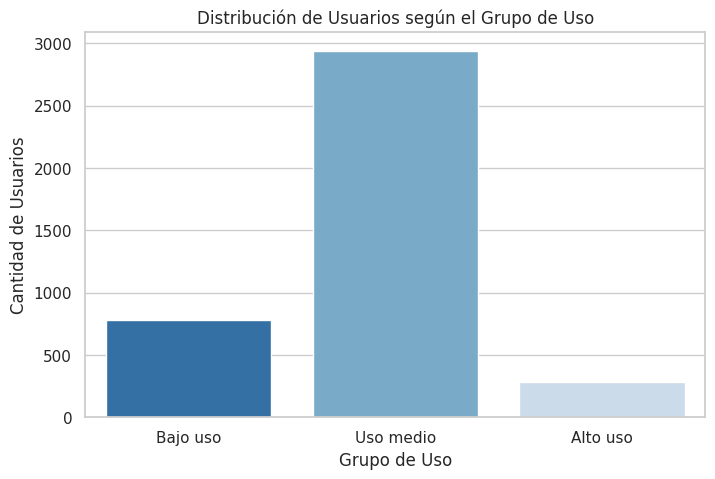

In [ ]:
# Visualización de los segmentos por uso
sns.set_theme(style="whitegrid")

# 1. Visualización de los segmentos por uso
plt.figure(figsize=(8, 5))
sns.countplot(
    data=user_profile,
    x='grupo_uso',
    order=['Bajo uso', 'Uso medio', 'Alto uso'],
    palette='Blues_r'
)
plt.title('Distribución de Usuarios según el Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

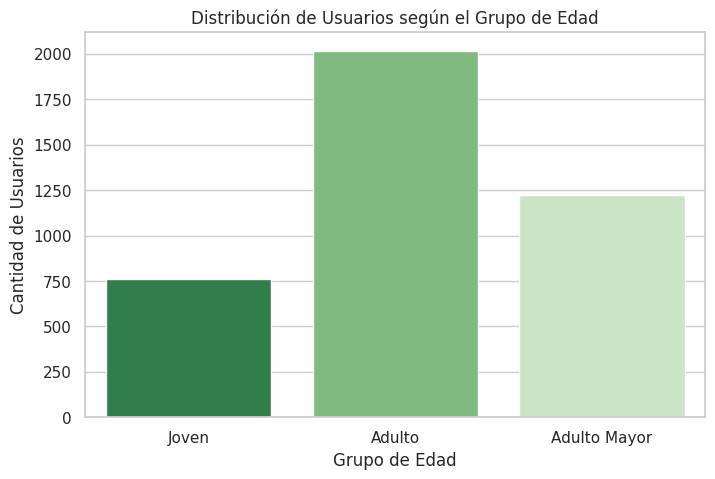

In [ ]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8, 5))
sns.countplot(
    data=user_profile,
    x='grupo_edad',
    order=['Joven', 'Adulto', 'Adulto Mayor'],
    palette='Greens_r'
)
plt.title('Distribución de Usuarios según el Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:**

### 1. ¿Qué problemas tenían los datos originalmente y cómo se solucionaron?
* **El problema:** La tabla de consumo (`usage`) tenía valores vacíos (`NaN`) al combinarse con los usuarios. Esto pasaba porque algunos clientes simplemente no hicieron llamadas ni enviaron mensajes en ese periodo.
* **Volumen e impacto:** Representaban a todos los usuarios que no tuvieron actividad.
* **La solución:** En lugar de borrar a esos usuarios (lo que nos haría perder clientes de la base), usé el comando `.fillna(0)` para cambiar esos `NaN` por `0`. Así mantuve al 100% de los usuarios registrados y dejé la tabla lista para calcular promedios reales.

---

### 2. ¿Qué segmentos de clientes identifiqué y cómo se comportan?
Creé dos nuevas columnas para clasificar a los usuarios de forma sencilla:
1. **Por Edad (`grupo_edad`):**
   * Dividí a los clientes en **Jóvenes** (<30), **Adultos** (30 a 59) y **Adultos Mayores** (60+). Vi que la edad está repartida de forma uniforme (no hay un grupo gigante que domine a los demás).
2. **Por Nivel de Uso (`grupo_uso`):**
   * **Bajo uso:** Menos de 5 llamadas y 5 mensajes (la mayoría usa plan Básico).
   * **Uso medio:** Entre 5 y 9 llamadas/mensajes.
   * **Alto uso:** 10 o más llamadas o mensajes (la gran mayoría está en el plan Premium).

---

### 3. ¿Qué clientes son los más valiosos para ConnectaTel y por qué?
* **El segmento más valioso:** Los clientes de **Alto Uso** que están en el **Plan Premium**.
* **¿Por qué?** Porque son los que más utilizan el servicio de llamadas y mensajes diariamente. Al estar en el plan más completo, son los clientes que le generan mayores ingresos a la empresa.

---

### 4. ¿Qué encontré sobre los valores extremos (outliers)?
* **Lo que vi en los gráficos:** Al hacer los *Boxplots*, noté que en `cant_mensajes`, `cant_llamadas` y `cant_minutos_llamada` aparecían varios puntos alejados arriba a la derecha (valores extremos muy altos). En la edad (`age`) no hubo ningún outlier.
* **Mi decisión:** Decidí **mantener los outliers** y no eliminarlos.
* **¿Por qué?** Porque en telefonía es normal que existan usuarios que llaman o envían muchísimos mensajes (*superusuarios*). No eran errores de captura ni datos falsos, sino clientes reales que usan mucho el teléfono. Borrarlos daría una falsa imagen de cómo se usa la red.

---

### 5. ¿Qué recomendaciones le daría a la empresa?
1. **Crear un plan más económico:** Hay muchos usuarios en "Bajo Uso" que casi no usan el teléfono. Se les podría ofrecer un plan más pequeño para que no cancelen el servicio.
2. **Invitar a los de Uso Medio a subirse de plan:** A los usuarios con plan Básico que están en "Uso Medio", se les puede enviar una promoción para que se pasen al plan Premium.
3. **Cuidar a los usuarios de Alto Uso:** A los clientes que consumen muchos minutos (los outliers altos), hay que darles buen soporte o beneficios extra para que no se vayan con la competencia.


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

Datos vacíos (NaN): Al unir la tabla de usuarios con la de consumos, aparecieron valores nulos en clientes sin actividad.

Solución aplicada: Se imputaron con 0 (.fillna(0)) para conservar al 100% de los usuarios sin distorsionar la base de datos.

🔍 Segmentos por Edad
Grupos creados: Jóvenes (<30 años), Adultos (30–59 años) y Adultos Mayores (60+ años).

Distribución: La edad de los usuarios es homogénea y uniforme; no existe un sesgo por edad en la contratación de planes.

📊 Segmentos por Nivel de Uso
Bajo uso: Clientes con menos de 5 llamadas y 5 mensajes (concentrados principalmente en el plan Básico).

Uso medio: Clientes con consumo moderado (entre 5 y 9 llamadas o mensajes).

Alto uso: Clientes de uso intensivo con 10 o más llamadas o mensajes (la mayoría concentrados en el plan Premium).

➡️ Esto sugiere que ...
Existe una clara relación entre el consumo del usuario y el tipo de plan que contrata.

Los usuarios con mayor frecuencia de uso justifican el costo del plan Premium, mientras que los de menor consumo se quedan en el plan Básico.

Los valores atípicos (outliers) detectados en llamadas y mensajes corresponden a usuarios reales de consumo intensivo que no deben ser eliminados.

💡 Recomendaciones
Retención en Bajo Uso: Diseñar un paquete básico económico para evitar la cancelación de usuarios con muy poco tráfico.

Estrategia: Lanzar promociones para que los clientes de Uso Medio en el plan Básico se migren al plan Premium.

Planes a la medida: Crear beneficios especiales para el segmento de Alto Uso (como minutos o mensajes ilimitados) para afianzar a los clientes de mayor valor.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`